# Imports

In [1]:
import os
import numpy as np
from tqdm.notebook import tqdm
from scipy.signal import resample
import xml.etree.ElementTree as ET
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Input, Dense, LSTM
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from matplotlib import pyplot as plt
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Constants

In [2]:
NUM_POINTS = 50

NOTEBOOK_DIR = os.path.abspath('')
TRAIN_DIR = os.path.join(NOTEBOOK_DIR, "..", "logs")
TEST_DIR = os.path.join(NOTEBOOK_DIR, "..", "datasets")

# classes to exclude from training/testing pool (none needed yet; question_mark
# stays in for the LSTM, only excluded later when comparing against $1)
EXCLUDE_CLASSES = set()

# Load data

In [3]:
def load_xml_samples(root_dir, exclude_classes=None):
    exclude_classes = exclude_classes or set()
    data = []
    for root, subdirs, files in os.walk(root_dir):
        if 'ipynb_checkpoint' in root:
            continue
        xml_files = [f for f in files if f.endswith('.xml')]
        if not xml_files:
            continue
        for f in tqdm(xml_files, desc=root):
            fname = f.split('.')[0]
            label = fname.rstrip('0123456789')  # strip trailing digits (rep number)

            if label in exclude_classes:
                continue

            xml_root = ET.parse(os.path.join(root, f)).getroot()

            points = []
            for element in xml_root.findall('Point'):
                x = element.get('X')
                y = element.get('Y')
                points.append([x, y])

            points = np.array(points, dtype=float)

            scaler = StandardScaler()
            points = scaler.fit_transform(points)

            resampled = resample(points, NUM_POINTS)

            data.append((label, resampled))
    return data

In [4]:

train_data = load_xml_samples(TRAIN_DIR)
test_data = load_xml_samples(TEST_DIR)

print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")
print(f"Training classes: {sorted(set(label for label, _ in train_data))}")
print(f"Test classes: {sorted(set(label for label, _ in test_data))}")

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

...

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-06-gesture-recognition-martinarobyculas…

Training samples: 5280
Test samples: 160
Training classes: ['arrow', 'caret', 'check', 'circle', 'delete_mark', 'left_curly_brace', 'left_sq_bracket', 'pigtail', 'question_mark', 'rectangle', 'right_curly_brace', 'right_sq_bracket', 'star', 'triangle', 'v', 'x']
Test classes: ['arrow', 'caret', 'check', 'circle', 'delete_mark', 'left_curly_brace', 'left_sq_bracket', 'pigtail', 'question_mark', 'rectangle', 'right_curly_brace', 'right_sq_bracket', 'star', 'triangle', 'v', 'x']


In [5]:
data = []

for root, subdirs, files in os.walk('../logs'):
    if 'ipynb_checkpoint' in root:
        continue
    
    if len(files) > 0:
        for f in tqdm(files):
            if '.xml' in f:
                fname = f.split('.')[0]
                label = fname[:-2]
                
                xml_root = ET.parse(f'{root}/{f}').getroot()
                
                points = []
                for element in xml_root.findall('Point'):
                    x = element.get('X')
                    y = element.get('Y')
                    points.append([x, y])
                    
                points = np.array(points, dtype=float)
                
                scaler = StandardScaler()
                points = scaler.fit_transform(points)
                
                resampled = resample(points, NUM_POINTS)
                
                data.append((label, resampled))

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

...

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

In [6]:
test_data = []

for root, subdirs, files in os.walk('../datasets'):
    if 'ipynb_checkpoint' in root:
        continue
    
    if len(files) > 0:
        for f in tqdm(files):
            if '.xml' in f:
                fname = f.split('.')[0]
                label = fname[:-2]
                
                xml_root = ET.parse(f'{root}/{f}').getroot()
                
                points = []
                for element in xml_root.findall('Point'):
                    x = element.get('X')
                    y = element.get('Y')
                    points.append([x, y])
                    
                points = np.array(points, dtype=float)
                
                scaler = StandardScaler()
                points = scaler.fit_transform(points)
                
                resampled = resample(points, NUM_POINTS)
                
                test_data.append((label, resampled))

  0%|          | 0/161 [00:00<?, ?it/s]

# Prepare data

In [7]:
# Prepare the data
labels = [sample[0] for sample in data]
print("labels: ", set(labels))

# encode (make string-labels numerical)
encoder = LabelEncoder()
labels_encoded = encoder.fit_transform(labels)
print("encoded: ", set(labels_encoded))

# get labels of data
y = to_categorical(labels_encoded)
print("num labels (encoded): ", len(y[0]))

# get point sequences of data
sequences = [sample[1] for sample in data]
X = np.array(sequences)

# split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

labels:  {'star', 'v', 'x', 'check', 'circle', 'pigtail', 'right_sq_bracket', 'question_mark', 'triangle', 'rectangle', 'caret', 'arrow', 'delete_mark', 'right_curly_brace', 'left_sq_bracket', 'left_curly_brace'}
encoded:  {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)}
num labels (encoded):  16
(4224, 50, 2) (1056, 50, 2) (4224, 16) (1056, 16)


In [8]:
# prepare my own captured data as the final test set (separate from Wobbrock's data)
test_labels = [sample[0] for sample in test_data]
test_labels_encoded = encoder.transform(test_labels)
y_test = to_categorical(test_labels_encoded, num_classes=len(encoder.classes_))

test_sequences = [sample[1] for sample in test_data]
X_test = np.array(test_sequences)

print(X_test.shape, y_test.shape)

(160, 50, 2) (160, 16)


# Models

In [9]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
stop_early = EarlyStopping(monitor='val_loss', patience=3)

## Definition

### Large
Baseline model, demo notebook from GRIPS

In [10]:
model_large = Sequential()

# add LSTM layer
# input shape is (length of an individual sample, dimensions of the sample)
# in our case: two dimensions, as we have X and Y coordinates

model_large.add(Input((NUM_POINTS, 2)))
model_large.add(LSTM(64))

# add dense layer to do machine learning magic
model_large.add(Dense(32, activation='relu'))

# softmax layer for classification
model_large.add(Dense(len(set(labels)), activation='softmax'))

# Compile the model
model_large.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_large.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,760 (77.19 KB)

 Trainable params: 19,760 (77.19 KB)

 Non-trainable params: 0 (0.00 B)

### Medium

In [11]:
model_medium = Sequential()

model_medium.add(Input((NUM_POINTS, 2)))
model_medium.add(LSTM(32))
model_medium.add(Dense(16, activation='relu'))
model_medium.add(Dense(len(set(labels)), activation='softmax'))

model_medium.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_medium.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,280 (20.62 KB)

 Trainable params: 5,280 (20.62 KB)

 Non-trainable params: 0 (0.00 B)

### Small

In [12]:
model_small = Sequential()

model_small.add(Input((NUM_POINTS, 2)))
model_small.add(LSTM(16))
model_small.add(Dense(8, activation='relu'))
model_small.add(Dense(len(set(labels)), activation='softmax'))

model_small.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_small.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 16)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           144 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,496 (5.84 KB)

 Trainable params: 1,496 (5.84 KB)

 Non-trainable params: 0 (0.00 B)

## Training

### Large

In [13]:
# train the large model
history_large = model_large.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[reduce_lr, stop_early]
)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6172 - loss: 1.3737 - val_accuracy: 0.9242 - val_loss: 0.3515 - learning_rate: 0.0010
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9387 - loss: 0.2462 - val_accuracy: 0.9583 - val_loss: 0.1571 - learning_rate: 0.0010
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9683 - loss: 0.1254 - val_accuracy: 0.9763 - val_loss: 0.0858 - learning_rate: 0.0010
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9815 - loss: 0.0765 - val_accuracy: 0.9848 - val_loss: 0.0667 - learning_rate: 0.0010
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9759 - loss: 0.0865 - val_accuracy: 0.9697 - val_loss: 0.0881 - learning_rate: 0.0010
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9924 - loss: 0.0373 - val_accuracy: 0.9830 - val_loss: 0.0723 - learning_rate: 0.0010
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9948 - loss: 0.

### Medium

In [14]:
# train the medium model
history_medium = model_medium.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[reduce_lr, stop_early]
)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3383 - loss: 2.0717 - val_accuracy: 0.6847 - val_loss: 1.2047 - learning_rate: 0.0010
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7898 - loss: 0.7202 - val_accuracy: 0.8674 - val_loss: 0.4581 - learning_rate: 0.0010
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9129 - loss: 0.4010 - val_accuracy: 0.9100 - val_loss: 0.3797 - learning_rate: 2.0000e-04


### Small

In [15]:
# train the small model
history_small = model_small.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[reduce_lr, stop_early]
)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.1771 - loss: 2.4432 - val_accuracy: 0.2169 - val_loss: 2.0903 - learning_rate: 0.0010
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4306 - loss: 1.6466 - val_accuracy: 0.6572 - val_loss: 1.2581 - learning_rate: 0.0010
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6745 - loss: 1.1952 - val_accuracy: 0.7064 - val_loss: 1.1388 - learning_rate: 2.0000e-04


# Training curves

### Large

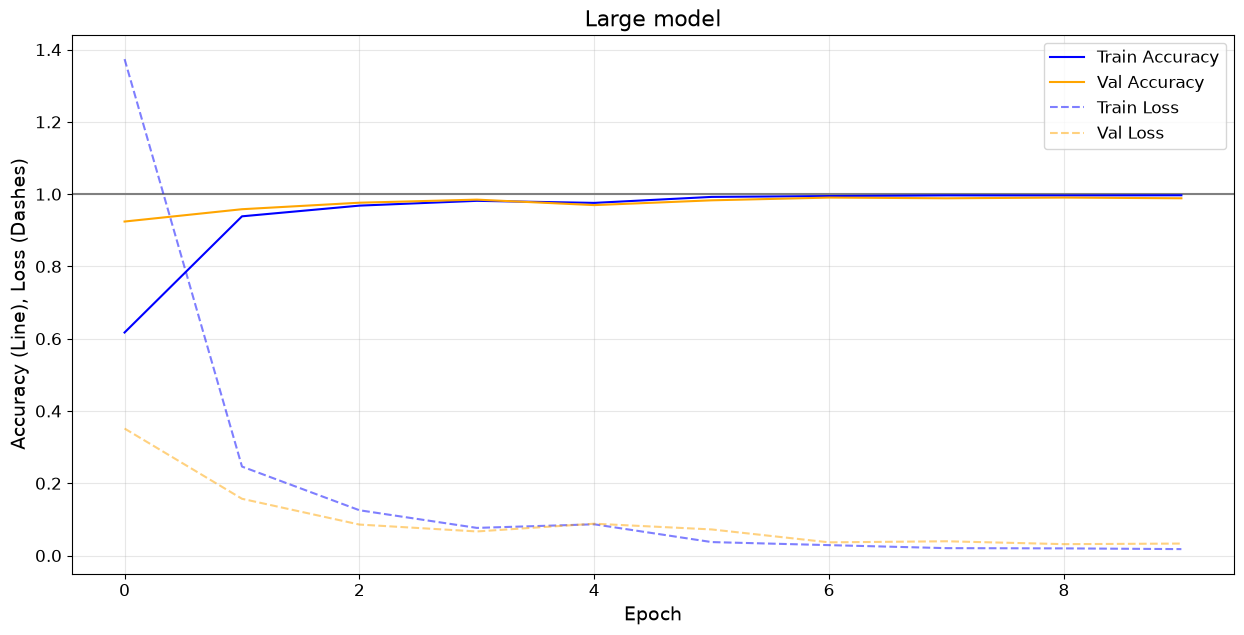

In [16]:
loss = history_large.history['loss']
val_loss = history_large.history['val_loss']
accuracy = history_large.history['accuracy']
val_accuracy = history_large.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch', fontsize=14)
ax.set_ylabel('Accuracy (Line), Loss (Dashes)', fontsize=14)
ax.tick_params(axis='both', labelsize=12)

ax.axhline(1, color='gray')
ax.grid(True, alpha=0.3)

plt.plot(accuracy, color='blue', label='Train Accuracy')
plt.plot(val_accuracy, color='orange', label='Val Accuracy')
plt.plot(loss, '--', color='blue', alpha=0.5, label='Train Loss')
plt.plot(val_loss, '--', color='orange', alpha=0.5, label='Val Loss')

plt.title('Large model', fontsize=16)
plt.legend(fontsize=12)
plt.show()

### Medium

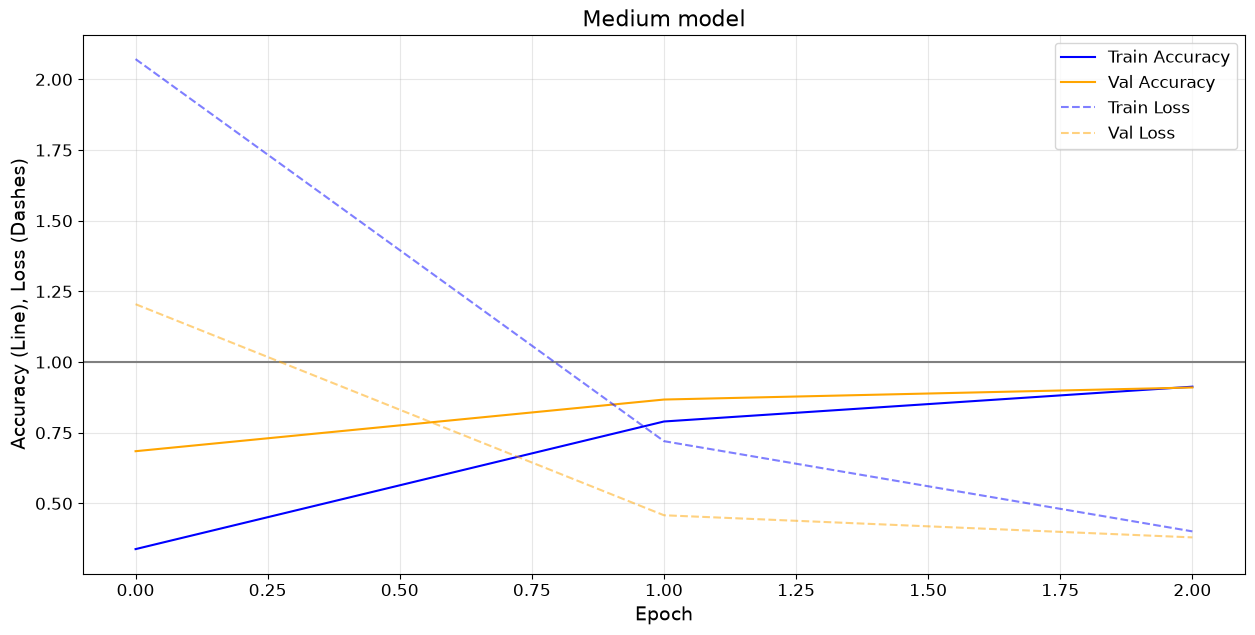

In [17]:
loss = history_medium.history['loss']
val_loss = history_medium.history['val_loss']
accuracy = history_medium.history['accuracy']
val_accuracy = history_medium.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch', fontsize=14)
ax.set_ylabel('Accuracy (Line), Loss (Dashes)', fontsize=14)
ax.tick_params(axis='both', labelsize=12)

ax.axhline(1, color='gray')
ax.grid(True, alpha=0.3)

plt.plot(accuracy, color='blue', label='Train Accuracy')
plt.plot(val_accuracy, color='orange', label='Val Accuracy')
plt.plot(loss, '--', color='blue', alpha=0.5, label='Train Loss')
plt.plot(val_loss, '--', color='orange', alpha=0.5, label='Val Loss')

plt.title('Medium model', fontsize=16)
plt.legend(fontsize=12)
plt.show()

### Small

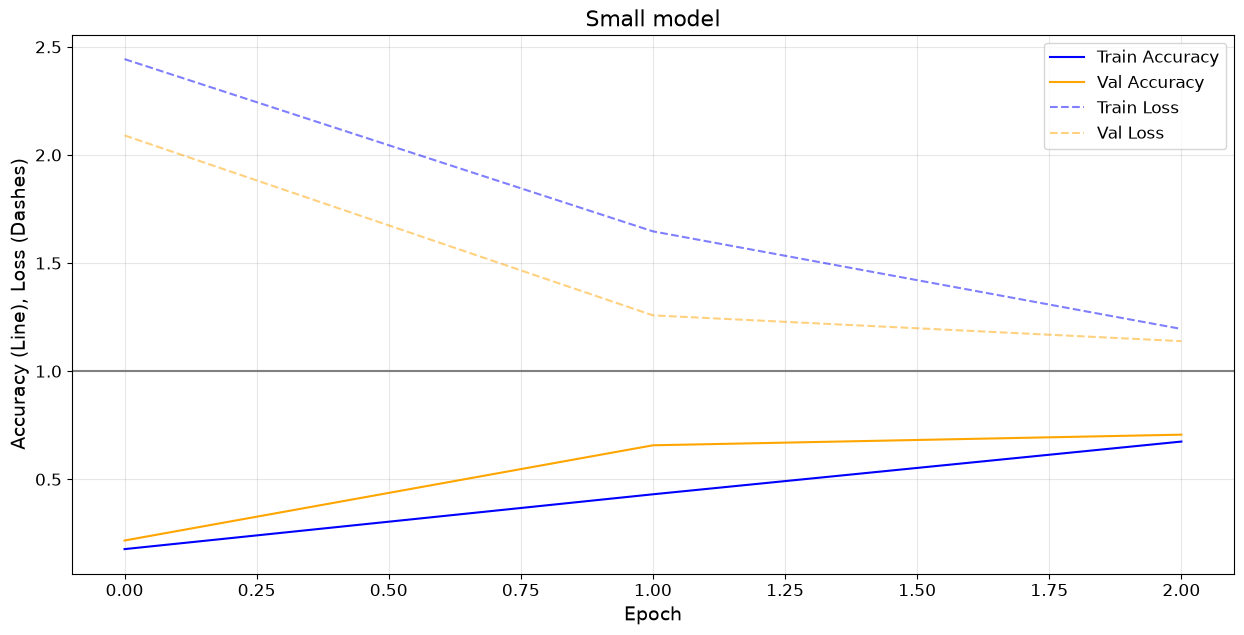

In [18]:
loss = history_small.history['loss']
val_loss = history_small.history['val_loss']
accuracy = history_small.history['accuracy']
val_accuracy = history_small.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch', fontsize=14)
ax.set_ylabel('Accuracy (Line), Loss (Dashes)', fontsize=14)
ax.tick_params(axis='both', labelsize=12)

ax.axhline(1, color='gray')
ax.grid(True, alpha=0.3)

plt.plot(accuracy, color='blue', label='Train Accuracy')
plt.plot(val_accuracy, color='orange', label='Val Accuracy')
plt.plot(loss, '--', color='blue', alpha=0.5, label='Train Loss')
plt.plot(val_loss, '--', color='orange', alpha=0.5, label='Val Loss')

plt.title('Small model', fontsize=16)
plt.legend(fontsize=12)
plt.show()

# Predictions
On test data

### Large

#### Prediction time

In [19]:
# make predictions for all the samples in test data
t0 = time.time()
predictions_large = model_large.predict(X_test)
t1 = time.time()

prediction_time_large = (t1 - t0) / len(X_test)  # average time per sample
print(f"Average prediction time (large model): {prediction_time_large*1000:.3f} ms/sample")

predicted_labels_large = np.argmax(predictions_large, axis=1)
true_labels_large = np.argmax(y_test, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 
Average prediction time (large model): 1.797 ms/sample


#### Accuracy

In [20]:
# print accuracy of model on test data
accuracy_large = np.mean(predicted_labels_large == true_labels_large)
print(f"Test accuracy (large model): {accuracy_large:.4f}")

Test accuracy (large model): 0.9563


#### Confusion matrix

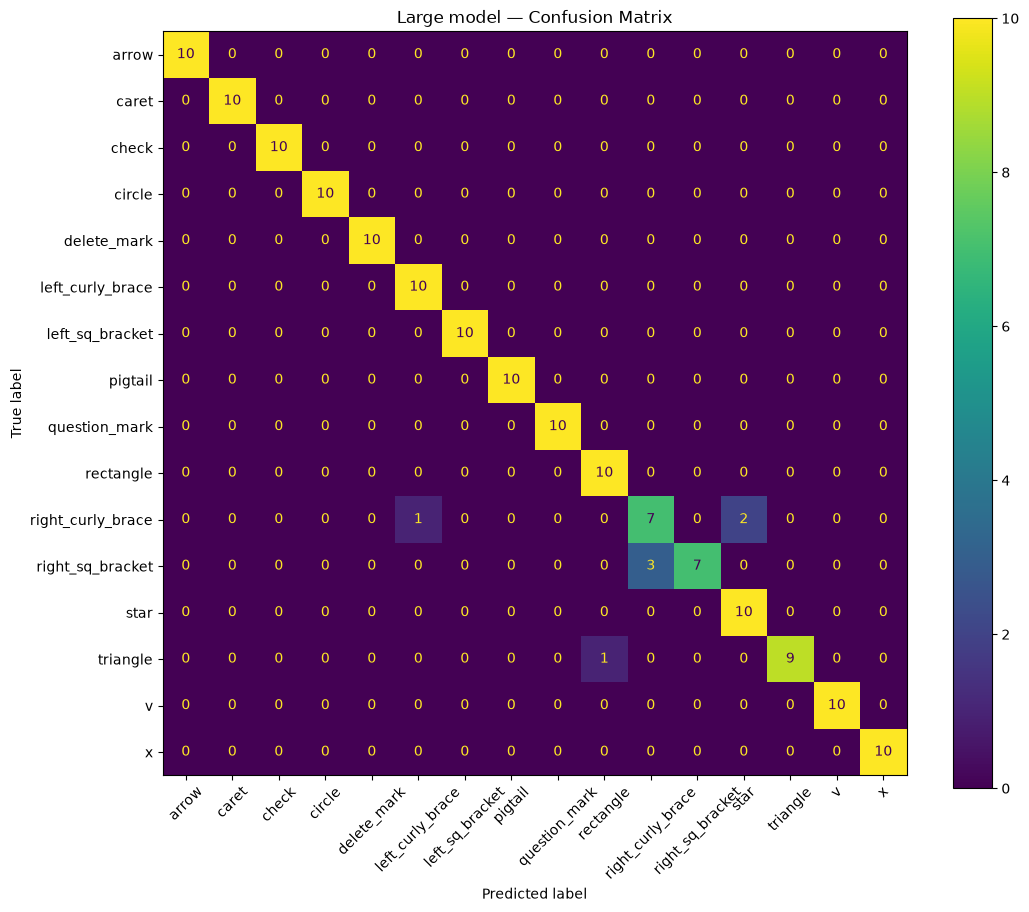

In [21]:
# show confusion matrix
cm_large = confusion_matrix(true_labels_large, predicted_labels_large)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_large, display_labels=encoder.classes_)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title('Large model — Confusion Matrix')
plt.show()

### Medium

#### Prediction time

In [22]:
# make predictions for all the samples in test data
t0 = time.time()
predictions_medium = model_medium.predict(X_test)
t1 = time.time()

prediction_time_medium = (t1 - t0) / len(X_test)  # average time per sample
print(f"Average prediction time (medium model): {prediction_time_medium*1000:.3f} ms/sample")

predicted_labels_medium = np.argmax(predictions_medium, axis=1)
true_labels_medium = np.argmax(y_test, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  
Average prediction time (medium model): 1.710 ms/sample


#### Accuracy

In [23]:
# print accuracy of model on test data
accuracy_medium = np.mean(predicted_labels_medium == true_labels_medium)
print(f"Test accuracy (medium model): {accuracy_medium:.4f}")

Test accuracy (medium model): 0.8875


#### Confusion matrix

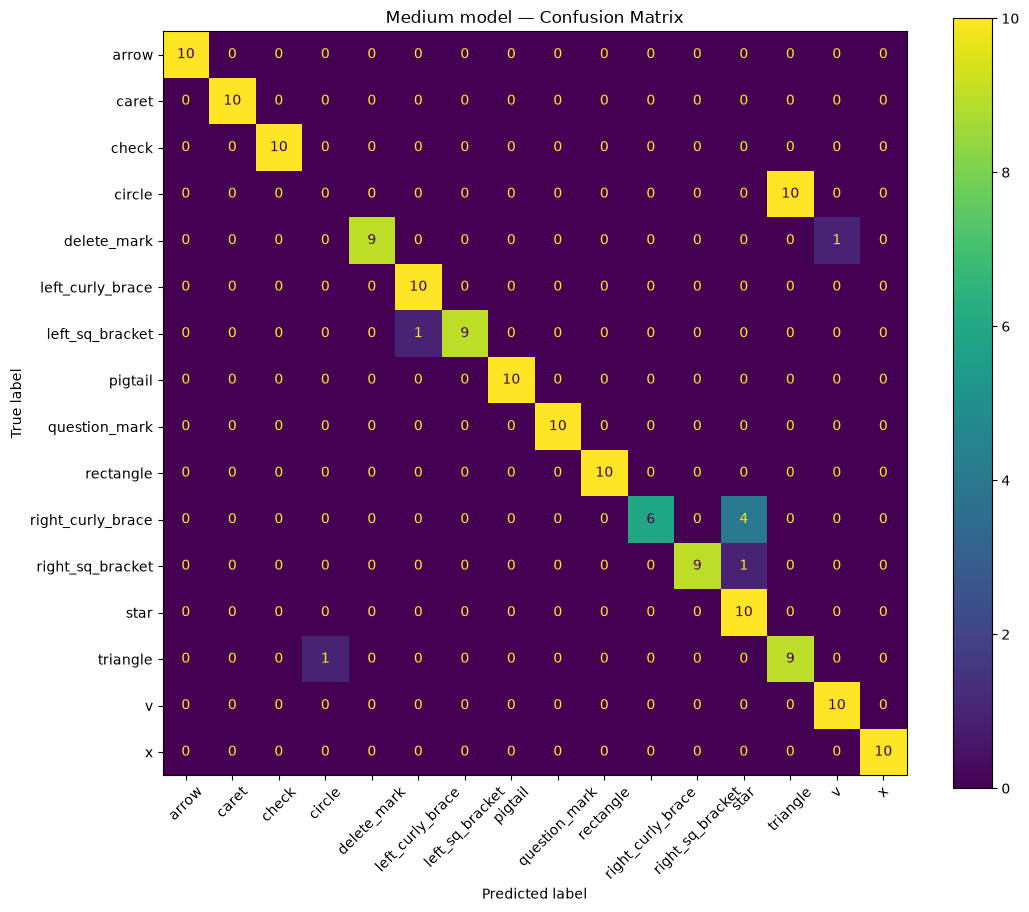

In [24]:
# show confusion matrix
cm_medium = confusion_matrix(true_labels_medium, predicted_labels_medium)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_medium, display_labels=encoder.classes_)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title('Medium model — Confusion Matrix')
plt.show()

### Small

#### Prediction time

In [25]:
# make predictions for all the samples in test data
t0 = time.time()
predictions_small = model_small.predict(X_test)
t1 = time.time()

prediction_time_small = (t1 - t0) / len(X_test)  # average time per sample
print(f"Average prediction time (small model): {prediction_time_small*1000:.3f} ms/sample")

predicted_labels_small = np.argmax(predictions_small, axis=1)
true_labels_small = np.argmax(y_test, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 
Average prediction time (small model): 1.704 ms/sample


#### Accuracy

In [26]:
# print accuracy of model on test data
accuracy_small = np.mean(predicted_labels_small == true_labels_small)
print(f"Test accuracy (small model): {accuracy_small:.4f}")

Test accuracy (small model): 0.5625


#### Confusion matrix

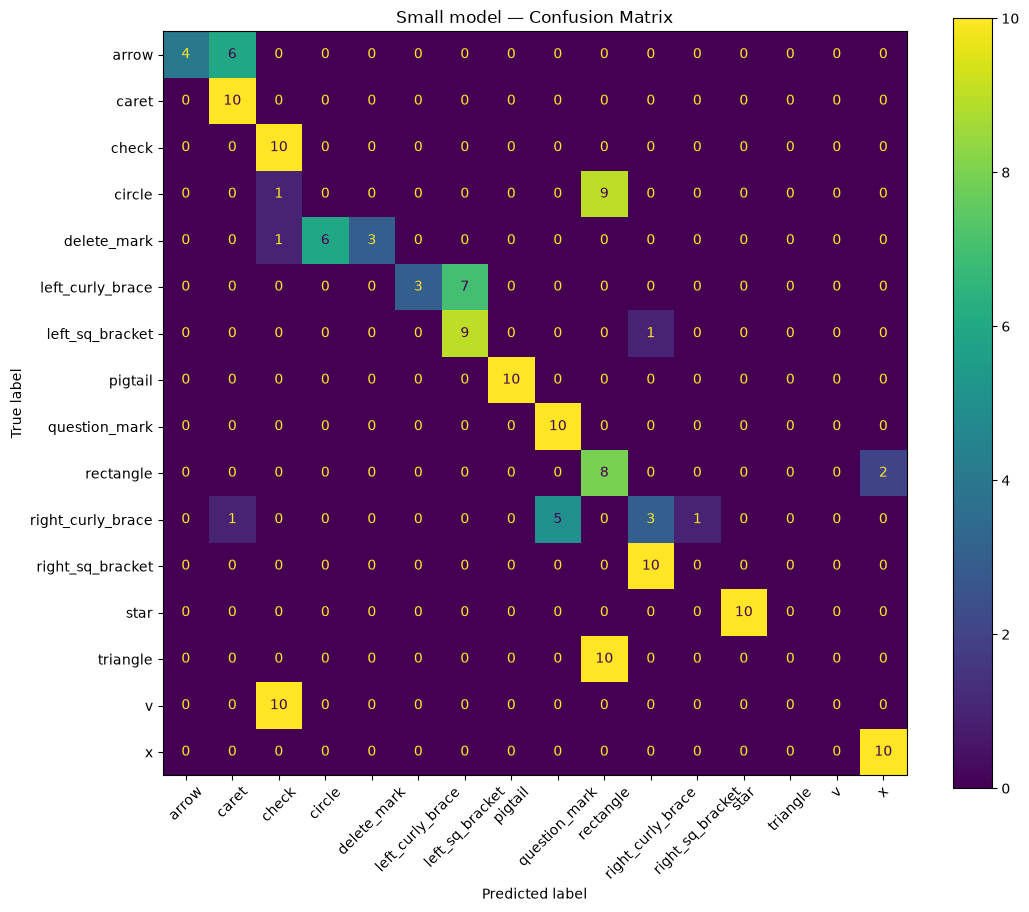

In [27]:
# show confusion matrix
cm_small = confusion_matrix(true_labels_small, predicted_labels_small)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_small, display_labels=encoder.classes_)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title('Small model — Confusion Matrix')
plt.show()

# $1 Gesture Recognizer

# Further analysis, plots and discussion